# Calculate mAP scores comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copairs import map
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_abline,
    geom_point,
    ggplot,
    labs,
    scale_color_gradientn,
    theme,
    theme_bw,
)
from plotnine.options import set_option

## Helper functions

In [ ]:
# Perform mean average precision calculation
def get_mean_average_precision(  # noqa: ANN201, PLR0913
    activity_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mean average precision for activity data.

    Args:
        activity_df (pd.DataFrame): Activity data.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        seed (int, optional): Random seed for reproducibility. Defaults to 0.

    Returns:
        pd.DataFrame: Mean average precision results.
    """
    metadata = activity_df.filter(regex="^Metadata")
    profiles = activity_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    activity_ap = activity_ap.query("Metadata_broad_sample != 'DMSO'")

    activity_map = map.mean_average_precision(
        activity_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)
    return activity_map

# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)

## Load in the data for pre and post QC

In [3]:
# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for merged profiles
output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

In [4]:
# Compute percentage of failed QC single-cell across all plates in post_qc_df
total_failed = post_qc_df["Metadata_sc_count_failed_qc"].sum()
total_cells = post_qc_df["Metadata_sc_count"].sum()
failed_qc_percentage = (total_failed / total_cells) * 100
print(
    f"Percentage of failed QC single-cell across all plates: {failed_qc_percentage:.2f}%"
)

Percentage of failed QC single-cell across all plates: 29.03%


In [5]:
# Calculate proportion of failed cells for each well
post_qc_df["failed_proportion"] = post_qc_df["Metadata_sc_count_failed_qc"] / (
    post_qc_df["Metadata_sc_count_failed_qc"]
    + post_qc_df["Metadata_sc_count_passed_qc"]
)

# Compare failed proportions between compounds and DMSO
compound_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] != "DMSO", "failed_proportion"
]
dmso_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] == "DMSO", "failed_proportion"
]

# Print mean failed proportions
print(f"Mean failed proportion (compounds): {compound_failed.mean():.4f}")
print(f"Mean failed proportion (DMSO): {dmso_failed.mean():.4f}")

Mean failed proportion (compounds): 0.3019
Mean failed proportion (DMSO): 0.2970


## Assign reference index

In [6]:
reference_col = "Metadata_reference_index"

pre_qc_df_activity = assign_reference_index(
    pre_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles (neg controls)
    reference_col=reference_col,
    default_value=-1,
)

post_qc_df_activity = assign_reference_index(
    post_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles (neg controls)
    reference_col=reference_col,
    default_value=-1,
)

## Set positive and negative pairs for compounds

In [7]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]

## Calculate mAP scores per treatment compared to controls for both pre- and post-QC

### Pre-QC dataframe

In [8]:
list_of_dfs_map_preQC = []
for treatment in pre_qc_df_activity["Metadata_broad_sample"].unique():
    if treatment == "DMSO":
        continue
    treatment_plates = pre_qc_df_activity.loc[
        pre_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
    ].unique()
    treatment_df = pre_qc_df_activity[
        (
            (pre_qc_df_activity["Metadata_broad_sample"] == treatment)
            | (pre_qc_df_activity["Metadata_broad_sample"] == "DMSO")
        )
        & (pre_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
    ]
    # Check if there are at least two replicates for positive pairing
    n_replicates = treatment_df[
        treatment_df["Metadata_broad_sample"] == treatment
    ].shape[0]
    unique_pos_diffby = treatment_df[
        treatment_df["Metadata_broad_sample"] == treatment
    ][pos_diffby].drop_duplicates()
    if n_replicates < 2 or unique_pos_diffby.shape[0] < 2:
        print(
            f"Skipping treatment {treatment}: not enough replicates or "
            f"not enough unique '{pos_diffby}' values for positive pairs."
        )
        continue
    # Calculate average proportion of failed single cells per dose
    failed_cells = (
        treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
        .assign(
            Metadata_failed_prop=lambda x: x["Metadata_sc_count_failed_qc"]
            / x["Metadata_sc_count"]
        )
        .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
        .mean()
    )
    # Perform mAP calculation per treatment (use defaults)
    treatment_map = get_mean_average_precision(
        treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    # Map average failed cells to treatment_map
    treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
        "Metadata_dose_recode"
    ].map(failed_cells)
    list_of_dfs_map_preQC.append(treatment_map)

# Concatenate all treatment mAP results
final_map_preQC = pd.concat(list_of_dfs_map_preQC, ignore_index=True)
final_map_preQC["QC_status"] = "pre-QC"
# Save final mAP results to file
final_map_preQC.to_parquet(f"{output_dir}/final_map_scores_preQC.parquet", index=False)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

### Post-QC dataframe

In [9]:
list_of_dfs_map_postQC = []
for treatment in post_qc_df_activity["Metadata_broad_sample"].unique():
    if treatment == "DMSO":
        continue
    treatment_plates = post_qc_df_activity.loc[
        post_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
    ].unique()
    treatment_df = post_qc_df_activity[
        (
            (post_qc_df_activity["Metadata_broad_sample"] == treatment)
            | (post_qc_df_activity["Metadata_broad_sample"] == "DMSO")
        )
        & (post_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
    ]
    # Check if there are at least two replicates for positive pairing
    n_replicates = treatment_df[
        treatment_df["Metadata_broad_sample"] == treatment
    ].shape[0]
    unique_pos_diffby = treatment_df[
        treatment_df["Metadata_broad_sample"] == treatment
    ][pos_diffby].drop_duplicates()
    if n_replicates < 2 or unique_pos_diffby.shape[0] < 2:
        print(
            f"Skipping treatment {treatment}: not enough replicates or "
            f"not enough unique '{pos_diffby}' values for positive pairs."
        )
        continue
    # Calculate average proportion of failed single cells per dose
    failed_cells = (
        treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
        .assign(
            Metadata_failed_prop=lambda x: x["Metadata_sc_count_failed_qc"]
            / x["Metadata_sc_count"]
        )
        .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
        .mean()
    )
    # Perform mAP calculation per treatment (use defaults)
    treatment_map = get_mean_average_precision(
        treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    # Map average failed cells to treatment_map
    treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
        "Metadata_dose_recode"
    ].map(failed_cells)
    list_of_dfs_map_postQC.append(treatment_map)

# Concatenate all treatment mAP results
final_map_postQC = pd.concat(list_of_dfs_map_postQC, ignore_index=True)
final_map_postQC["QC_status"] = "post-QC"
# Save final mAP results to file
final_map_postQC.to_parquet(
    f"{output_dir}/final_map_scores_postQC.parquet", index=False
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

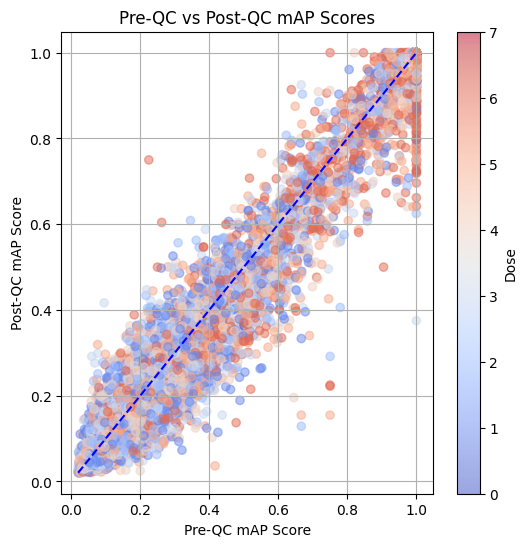

In [10]:
# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    merged_map["mean_average_precision_preQC"],
    merged_map["mean_average_precision_postQC"],
    c=merged_map["Metadata_dose_recode"],
    cmap="viridis",
    alpha=0.5,
)
plt.xlabel("Pre-QC mAP Score")
plt.ylabel("Post-QC mAP Score")
plt.title("Pre-QC vs Post-QC mAP Scores")
plt.grid(True)

# Add y = x reference line
lims = [
    min(
        merged_map["mean_average_precision_preQC"].min(),
        merged_map["mean_average_precision_postQC"].min(),
    ),
    max(
        merged_map["mean_average_precision_preQC"].max(),
        merged_map["mean_average_precision_postQC"].max(),
    ),
]
plt.plot(lims, lims, "b--", label="y = x")

cbar = plt.colorbar(scatter)
cbar.set_label("Dose")
scatter.set_cmap("coolwarm")

plt.show()

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/mAP_preQC_vs_postQC_by_dose.png


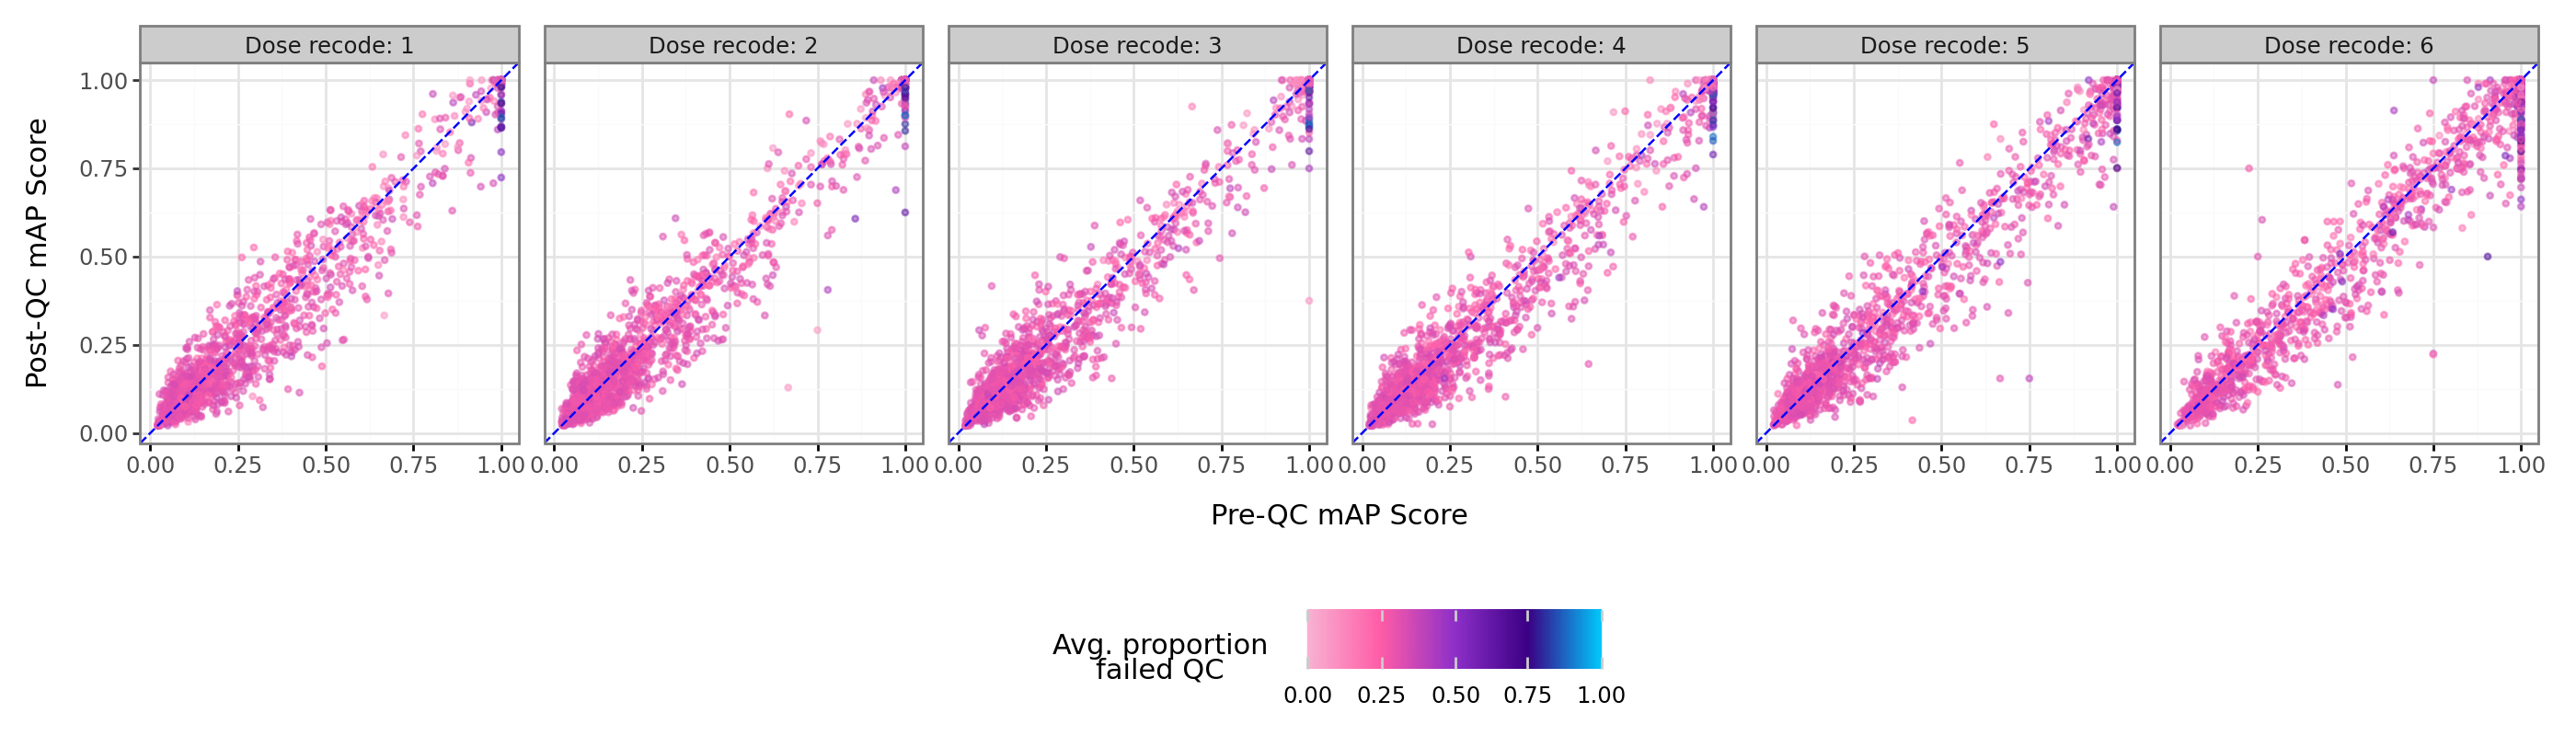

In [11]:
# Merge (as before)
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=[
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "Metadata_avg_prop_failed_single_cells",
    ],
    suffixes=("_preQC", "_postQC"),
)
# Drop rows with dose recode 0 and 7 due to low sample size
merged_map = merged_map[~merged_map["Metadata_dose_recode"].isin([0, 7])]

# Set the figure size
height = 4
width = 14
set_option("figure_size", (width, height))

# Define the custom coSMic QC palette (lighter pink to purple to cyan)
cosmicqc_palette = [
    "#f8b3d3",  # Light pink
    "#ff5ca7",  # Vibrant pink
    "#8f30c9",  # Medium purple
    "#3b0085",  # Deep purple
    "#00cafd",  # Cyan accent
]

# Make the plotnine plot
p = (
    ggplot(
        merged_map,
        aes(
            x="mean_average_precision_preQC",
            y="mean_average_precision_postQC",
            color="Metadata_avg_prop_failed_single_cells",
        ),
    )
    + geom_point(alpha=0.5, size=0.8)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="blue")
    + facet_wrap(
        "~Metadata_dose_recode", nrow=1, labeller=lambda x: f"Dose recode: {x}"
    )
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Pre-QC mAP Score",
        y="Post-QC mAP Score",
    )
    + theme_bw()
    + theme(
        legend_position="bottom",
    )
)

# Save as PNG
p.save("figures/mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    # rasterize scatter points only
    for coll in ax.collections:
        coll.set_rasterized(True)
    # keep lines and legend as vectors

# Save as SVG
fig.savefig("figures/mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

# To show the plot:
p.show()

In [ ]:
# Get proportion of points above and below y=x line
proportion_df = proportion_above_below_y_eq_x(merged_map)
proportion_df

,Metadata_dose_recode,proportion_above,proportion_below,proportion_equal,n_points
0,1,0.422508,0.529904,0.047588,1555
1,2,0.416988,0.520592,0.062420,1554
2,3,0.408360,0.495177,0.096463,1555
3,4,0.346624,0.533119,0.120257,1555
4,5,0.344093,0.535184,0.120723,1549
5,6,0.262306,0.506477,0.231218,1544


/tmp/ipykernel_202971/4223806310.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_202971/4223806310.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 12 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/

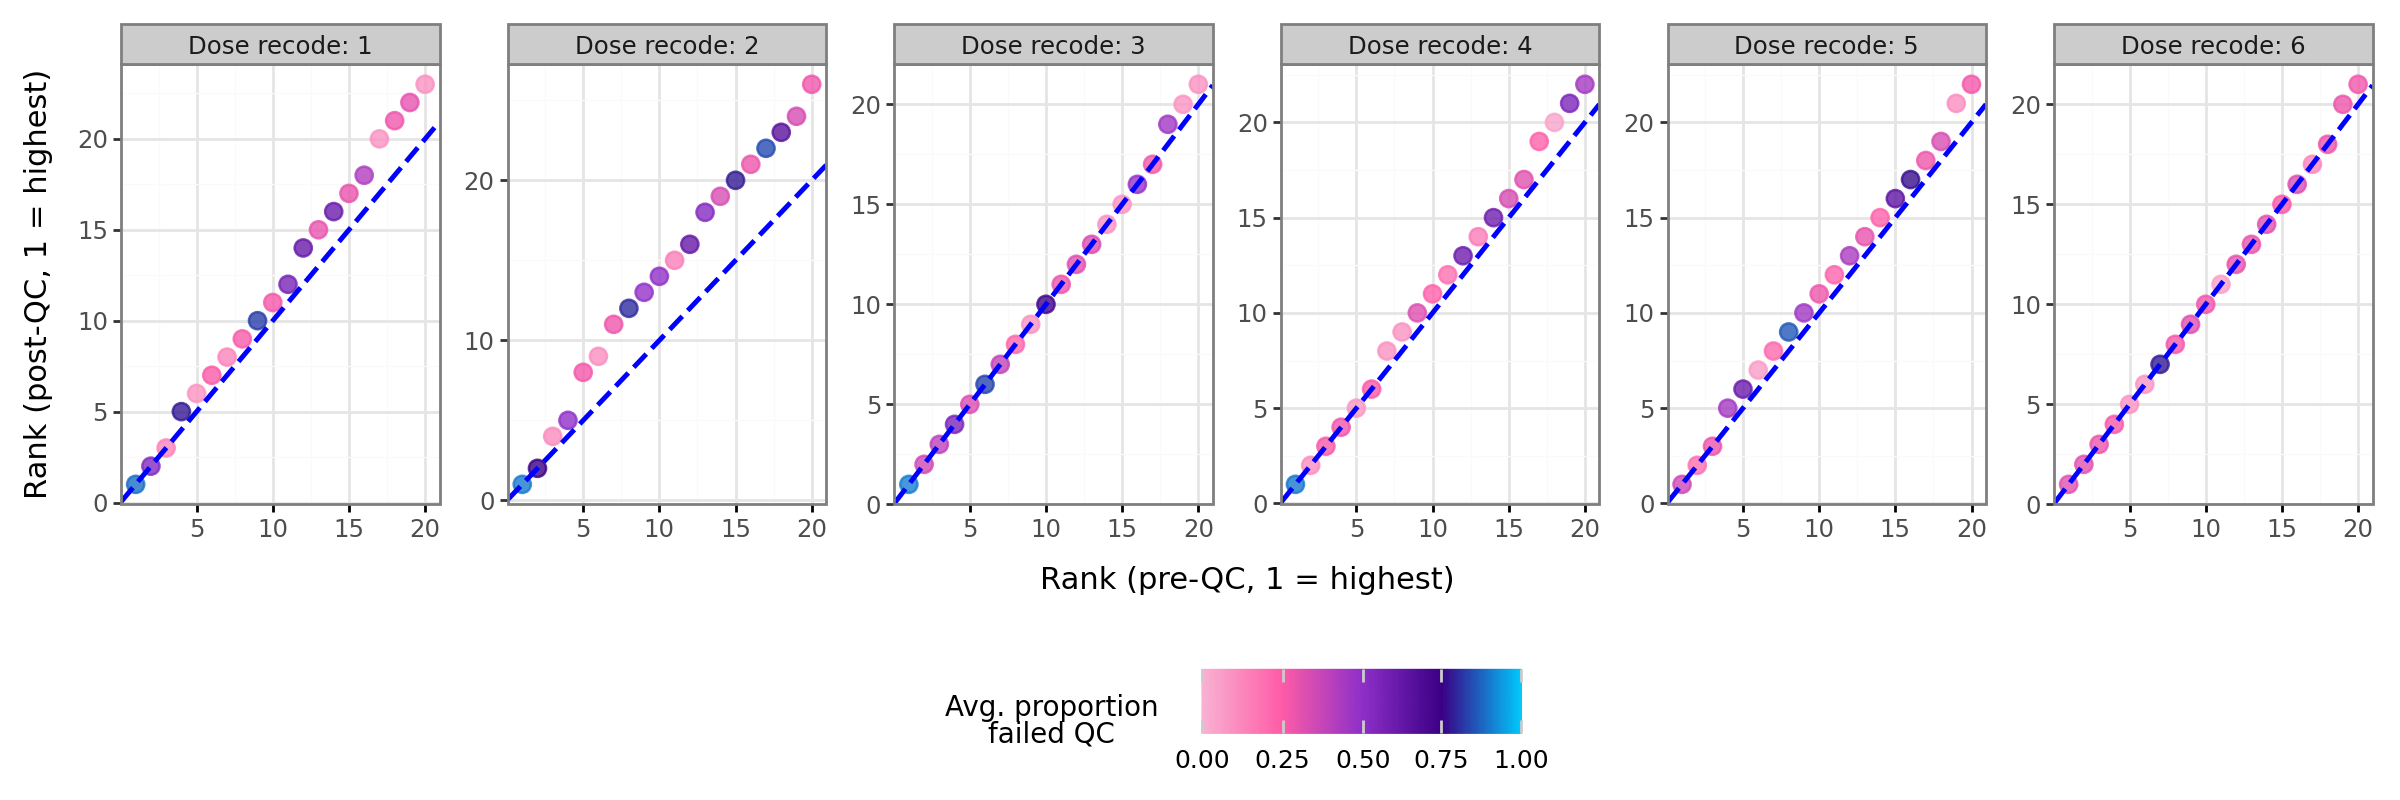

In [13]:
# Rank independently within each dose
merged_map_sorted = merged_map.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.sort_values("mean_average_precision_postQC", ascending=False).assign(
        postQC_rank=lambda d: np.arange(1, len(d) + 1)
    )
)

# Calculate rank pre-QC within each dose
merged_map_sorted["preQC_rank"] = merged_map_sorted.groupby("Metadata_dose_recode")[
    "mean_average_precision_preQC"
].rank(ascending=False, method="first")

# Keep top 20 compounds per dose based on preQC ranking
merged_map_top = (
    merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False)
    .apply(lambda df: df.nsmallest(20, "preQC_rank"))
    .copy()
)

# Use the custom palette
p = (
    ggplot(
        merged_map_top,
        aes(
            x="preQC_rank",
            y="postQC_rank",
            color="Metadata_avg_prop_failed_single_cells",
        ),
    )
    + geom_point(size=3, alpha=0.8)
    + geom_abline(intercept=0, slope=1, linetype="--", color="blue", size=1)
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Rank (pre-QC, 1 = highest)",
        y="Rank (post-QC, 1 = highest)",
        color="Avg prop failed cells",
    )
    + facet_wrap(
        "~Metadata_dose_recode",
        nrow=1,
        scales="free",
        labeller=lambda x: f"Dose recode: {x}",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 4),
        legend_position="bottom",
        legend_title=element_text(size=10),
        legend_text=element_text(size=9),
    )
)

# Save plots
p.save("figures/rank_mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    for coll in ax.collections:
        coll.set_rasterized(True)

fig.savefig("figures/rank_mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

p.show()